# Теория вероятностей в контексте наивного байесовского классификатора

## Дискретные распределения

### Равномерное распределение

Также мы можем определить ряд распределения для дискретного равномерного распределения с помощью Python. Импортируем библиотеку numpy и функцию randint() из библиотеки scipy, предназначенную для моделирования равномерного дискретного распределения:

In [1]:
import numpy as np
from scipy.stats import randint

Попробуем рассчитать вероятности для случайной величины, которая принимает значения от 1 включительно до 7 не включительно (собственно, это как раз пример с пирожными):

In [2]:
#Задаем возможные значения случайной величины
x = np.arange(1, 7)
#Задаем интервал, на котором будут распределяться наши вероятности
disc_uni_dist = randint(1, 7)
#Вычисляем вероятности выпадения каждого значения случайной величины
pmf = disc_uni_dist.pmf(x)

Получаем вероятности для каждого из шести значений:

In [4]:
print(pmf)

[0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]


Также мы можем найти кумулятивную вероятность для распределения, то есть для каждого  вероятность того, что случайная величина примет значение  или меньше:

In [5]:
#Рассчитываем кумулятивную вероятность
cdf = disc_uni_dist.cdf(x)

print(cdf)

[0.16666667 0.33333333 0.5        0.66666667 0.83333333 1.        ]


Теперь давайте попробуем с помощью функций Python решить другую задачу.

Вы участвуете в розыгрыше бесплатного места на новый курс по Data Science. Вы знаете, что участников 250.

Какова вероятность, что на курс попадёт кто-то из первых пятидесяти зарегистрировавшихся?

In [6]:
#Задаем возможные значения случайной величины
x = np.arange(1, 251)
#Задаем интервал, на котором будут распределяться наши вероятности
disc_uni_dist = randint(1, 251)
#Рассчитываем кумулятивную вероятность
cdf = disc_uni_dist.cdf(x)
#Ищем вероятность того, что на курс попадет кто-то из первых 50 зарегистрировавшихся
print(cdf[49])

0.2


### Распределение Бернулли

Вы стреляете по мишени в тире. Вероятность попасть составляет . В случае успеха вы выиграете плюшевого медведя стоимостью 3000 рублей, а в случае промаха — не выиграете ничего. У вас есть только один выстрел.

Какой должна быть стоимость билета, чтобы игра была честной, то есть чтобы цена билета равнялась ожидаемому выигрышу, а значит, не уводила в убыток продавца или вас при большом количестве выстрелов?

С помощью специальной функции bernoulli.rvs() из библиотеки scipy мы можем смоделировать распределение Бернулли и, например, увидеть ожидаемое соотношение попаданий и промахов для решённой задачи, если будет сделано 500 выстрелов:

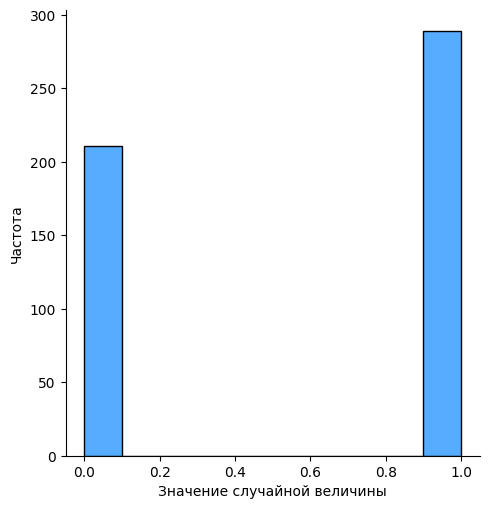

In [12]:
from scipy.stats import bernoulli
import seaborn as sns

data = bernoulli.rvs(size=500, p=0.6)
ax = sns.displot(data, kde=False, color = 'dodgerblue')
ax.set(xlabel='Значение случайной величины', ylabel='Частота');

Также можно вывести количество неудач и попаданий в нашей модели:

In [13]:
unique, counts = np.unique(data, return_counts=True)
print(np.asarray((unique, counts)).T)

[[  0 211]
 [  1 289]]


### Биномиальное распределение

Производитель гаджетов знает, что 20 % производимых им товаров — бракованные.

Если он производит десять изделий в день, какова вероятность того, что не более двух из них бракованные?

In [14]:
import scipy
scipy.stats.binom.pmf(8,10,0.8) + scipy.stats.binom.pmf(9,10,0.8) + scipy.stats.binom.pmf(10,10,0.8)

0.6777995264

Как и для распределения Бернулли, для биномиального распределения можно смоделировать какое-то количество попыток и получить результат. Например, можно смоделировать биноминальное распределение с параметром p = 0.5 и количеством испытаний, равным 10, и реализовать 1000 попыток:

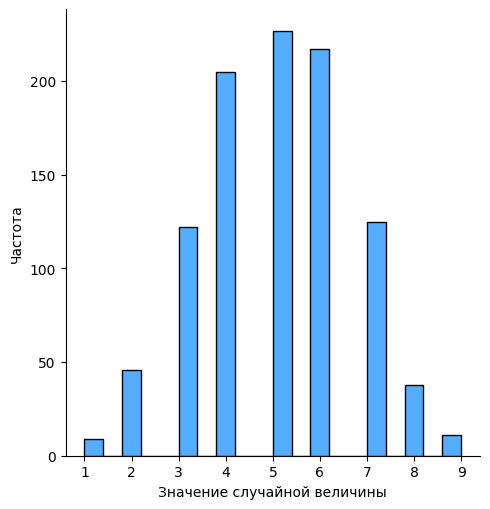

In [23]:
from numpy import random
import seaborn as sns

data = random.binomial(n=10, p=0.5, size=1000)
ax = sns.displot(data, kde=False, color='dodgerblue')
ax.set(xlabel='Значение случайной величины', ylabel='Частота');

### Распределение Пуассона

Колл-центр получает в среднем 4.5 звонка за каждые пять минут. Каждый оператор может обработать один из этих вызовов в течение пяти минут. Если вызов получен, но оператор  не может его принять, то вызывающий абонент будет переведён в режим ожидания ответа.

Если вызовы следуют распределению Пуассона, какое минимальное количество операторов необходимо колл-центру, чтобы вероятность попадания вызова на удержание была не более 0.1?

Разумеется, все эти значения можно было бы рассчитать намного проще с использованием функций Python. Например, для пяти операторов мы бы получили следующее выражение:

In [ ]:
import scipy

scipy.stats.distributions.poisson.pmf(5, 4.5)

0.17082685848611215

Также можно смоделировать распределение Пуассона. Например, будем рассматривать 1000 реализаций случайной величины, у которой λ = 3:

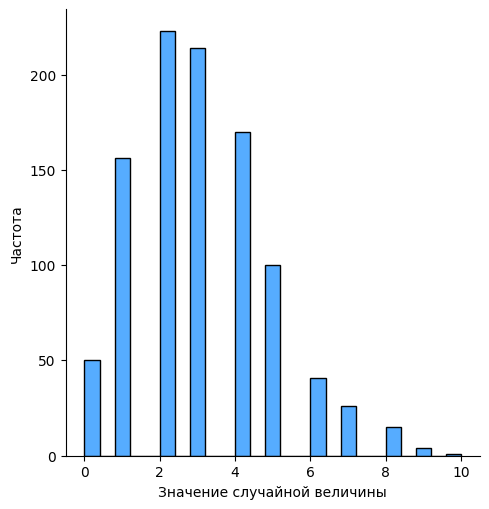

In [25]:
from numpy import random
import seaborn as sns

data = random.poisson(lam=3, size=1000)
ax = sns.displot(data, kde=False, color='dodgerblue')
ax.set(xlabel='Значение случайной величины', ylabel='Частота');

### Задача 8.7
Пассажиры прибывают на вокзал со средней скоростью λ = 4 человека в минуту.

Если количество пассажиров, приезжающих на вокзал, подчиняется распределению Пуассона, какова приблизительная вероятность того, что 16 пассажиров приедут на вокзал в конкретный четырёхминутный период? Округлите ответ до трёх знаков после точки-разделителя.



In [36]:
round(scipy.stats.distributions.poisson.pmf(16, 16), 3)

0.099

## Непрерывное распределение

### Равномерное распределение

Мы можем с помощью Python смоделировать случайную величину c таким распределением и визуализировать плотность её распределения. К примеру, сформируем выборку объёмом 10000 для распределения с параметрами  и :

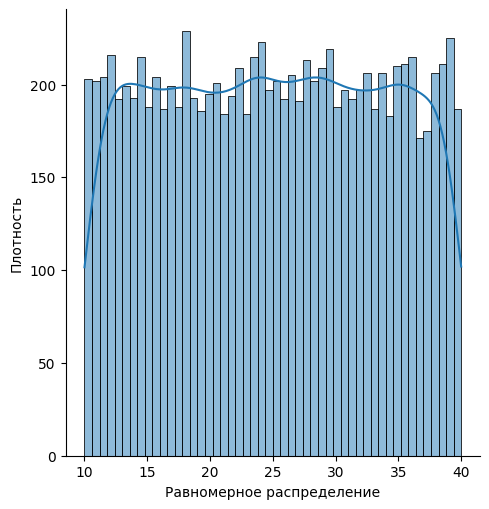

In [37]:
from scipy.stats import uniform
import seaborn as sns

data = uniform.rvs(size=10000, loc=10, scale=30)
ax = sns.displot(data, kde=True, bins=50)
ax.set(xlabel='Равномерное распределение', ylabel='Плотность');

### Нормальное распределение

Давайте смоделируем нормальное распределение с математическим ожиданием, равным , и стандартным отклонением, равным , и посмотрим, какой вид оно примет.

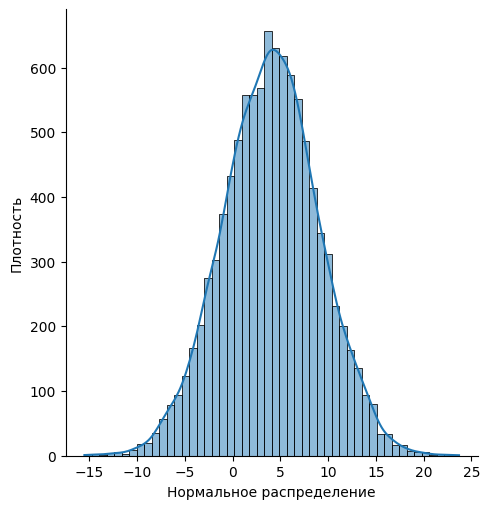

In [38]:
from scipy.stats import norm
import seaborn as sns

data = norm.rvs(size=10000, loc=4, scale=5)
ax = sns.displot(data, kde=True, bins=50)
ax.set(xlabel='Нормальное распределение', ylabel='Плотность');

С помощью Python мы можем стандартизировать данные следующим образом:

In [39]:
from numpy import asarray
from sklearn.preprocessing import StandardScaler
data = asarray([[93, 44],
                [4, 2],
                [36, 1],
                [14, 29],
                [78, 21]])
print(data)
scaler = StandardScaler()
scaled = scaler.fit_transform(data)
print(scaled)

[[93 44]
 [ 4  2]
 [36  1]
 [14 29]
 [78 21]]
[[ 1.37243726  1.50201177]
 [-1.17229016 -1.06239857]
 [-0.25733199 -1.12345596]
 [-0.88636573  0.58615094]
 [ 0.94355062  0.09769182]]


### Экспоненциальное распределение

С помощью Python мы можем смоделировать экспоненциальное распределение так:

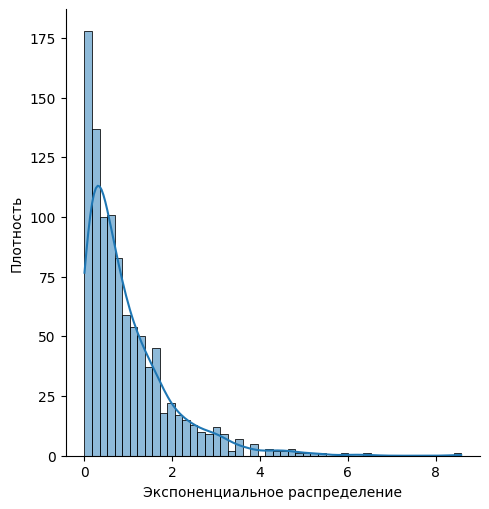

In [41]:
from scipy.stats import expon
import seaborn as sns

data = expon.rvs(scale=1, loc=0, size=1000)
ax = sns.displot(data, kde=True, bins=50)
ax.set(xlabel='Экспоненциальное распределение', ylabel='Плотность');